# 🤖 Machine Learning Fundamentals with scikit-learn

*A hands-on tutorial covering the complete ML workflow — from data generation to model tuning — using only synthetic data.*

---

### What You'll Learn

| Section | Topics |
|---------|--------|
| **Part 1 – The ML Workflow** | Supervised vs unsupervised learning, synthetic data generation, train/test splits |
| **Part 2 – Regression** | Linear, Ridge, Lasso & Decision-Tree regressors; model comparison |
| **Part 3 – Classification** | Logistic Regression, KNN, Decision Tree, Random Forest, SVM; ROC curves |
| **Part 4 – Unsupervised Learning** | K-Means, PCA, PCA + K-Means pipeline |
| **Part 5 – Model Tuning & Pipelines** | Cross-validation, GridSearchCV, sklearn Pipelines, learning curves |
| **Part 6 – Wrap-up** | Algorithm cheat-sheet, exercises, next steps |

> **Prerequisites:** Basic Python & NumPy knowledge.  All data is *synthetic* — no downloads required.


---
## Part 1: The ML Workflow

### What is Machine Learning?

Machine Learning (ML) is a subfield of artificial intelligence where models **learn patterns from data** instead of being explicitly programmed with rules.

| Paradigm | Goal | Examples |
|----------|------|----------|
| **Supervised** | Learn a mapping *X → y* from labelled data | Regression, Classification |
| **Unsupervised** | Discover hidden structure in unlabelled data | Clustering, Dimensionality Reduction |
| **Reinforcement** | Learn by interacting with an environment | Game-playing agents (not covered here) |

### The Typical ML Pipeline

```
Raw Data → Preprocessing → Feature Engineering → Train/Test Split
      → Model Training → Evaluation → Tuning → Deployment
```

> ⚠️ **Golden Rule:** Never let information from the *test* set leak into training. Always split first, then preprocess.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn utilities
from sklearn.model_selection import train_test_split

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports successful ✅")


All imports successful ✅


### Generating Synthetic Datasets

We use `sklearn.datasets` helpers to create perfectly controlled data.  This lets us:
- Know the **ground truth** (number of informative features, noise level, etc.)
- Reproduce results exactly via `random_state`
- Focus on the *algorithm*, not data cleaning


In [2]:
from sklearn.datasets import make_regression, make_classification, make_blobs

# --- Regression dataset ---
X_reg, y_reg = make_regression(
    n_samples=500, n_features=5, n_informative=3,
    noise=15.0, random_state=42
)
print(f"Regression  → X: {X_reg.shape}, y: {y_reg.shape}")

# --- Classification dataset ---
X_clf, y_clf = make_classification(
    n_samples=600, n_features=10, n_informative=5,
    n_redundant=2, n_classes=2, random_state=42
)
print(f"Classification → X: {X_clf.shape}, y: {y_clf.shape}")

# --- 2D classification (for decision-boundary plots) ---
X_clf2d, y_clf2d = make_classification(
    n_samples=400, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
print(f"Classification 2D → X: {X_clf2d.shape}, y: {y_clf2d.shape}")

# --- Clustering dataset ---
X_blobs, y_blobs = make_blobs(
    n_samples=400, centers=4, n_features=2,
    cluster_std=1.0, random_state=42
)
print(f"Clustering  → X: {X_blobs.shape}, y: {y_blobs.shape}")


Regression  → X: (500, 5), y: (500,)
Classification → X: (600, 10), y: (600,)
Classification 2D → X: (400, 2), y: (400,)
Clustering  → X: (400, 2), y: (400,)


### Train / Test Split

`train_test_split` randomly partitions data into a **training** set (used to fit the model) and a **test** set (used to evaluate performance on unseen data).

| Parameter | Purpose |
|-----------|---------|
| `test_size` | Fraction held out for testing (commonly 0.2–0.3) |
| `random_state` | Seed for reproducibility |
| `stratify` | Ensures class proportions are preserved (important for imbalanced datasets) |

> 💡 **Tip:** For classification, always pass `stratify=y` to avoid unlucky splits where one class is under-represented.


In [3]:
# Regression split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Classification split (stratified)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 2D classification split
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_clf2d, y_clf2d, test_size=0.2, random_state=42, stratify=y_clf2d
)

print(f"Regression  — train: {X_reg_train.shape}, test: {X_reg_test.shape}")
print(f"Classification — train: {X_clf_train.shape}, test: {X_clf_test.shape}")
print(f"Class balance (train): {np.bincount(y_clf_train)}")
print(f"Class balance (test):  {np.bincount(y_clf_test)}")


Regression  — train: (400, 5), test: (100, 5)
Classification — train: (480, 10), test: (120, 10)
Class balance (train): [239 241]
Class balance (test):  [60 60]


### Utility: Decision-Boundary Plotter

The helper below creates a dense grid over the feature space and colours each point by the classifier's prediction.  We will reuse it throughout the notebook.


In [4]:
def plot_decision_boundary(model, X, y, ax=None, title=None, alpha=0.3, h=0.05):
    """Plot the decision boundary of a fitted 2-D classifier."""
    if ax is None:
        fig, ax = plt.subplots()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=alpha, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap='RdYlBu')
    if title:
        ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    return ax

print("Helper function defined ✅")


Helper function defined ✅


---
## Part 2: Regression

Regression models predict a **continuous** target variable.  We will compare several regressors on our synthetic regression dataset.


### 4. Linear Regression

The simplest regression model fits a hyperplane $\hat{y} = X \mathbf{w} + b$ by minimising the **sum of squared residuals** (Ordinary Least Squares).

Key outputs:
- `coef_` — the weight vector **w**
- `intercept_` — the bias term **b**
- **R² score** — proportion of variance explained (1.0 = perfect)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
y_pred_lr = lr.predict(X_reg_test)

r2_lr = r2_score(y_reg_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_reg_test, y_pred_lr)

print(f"Coefficients : {lr.coef_.round(2)}")
print(f"Intercept    : {lr.intercept_:.2f}")
print(f"R² (test)    : {r2_lr:.4f}")
print(f"RMSE (test)  : {rmse_lr:.2f}")


Coefficients : [-5.500e-01  8.193e+01  2.000e-02  6.799e+01  1.185e+01]
Intercept    : -0.16
R² (test)    : 0.9798
RMSE (test)  : 15.34


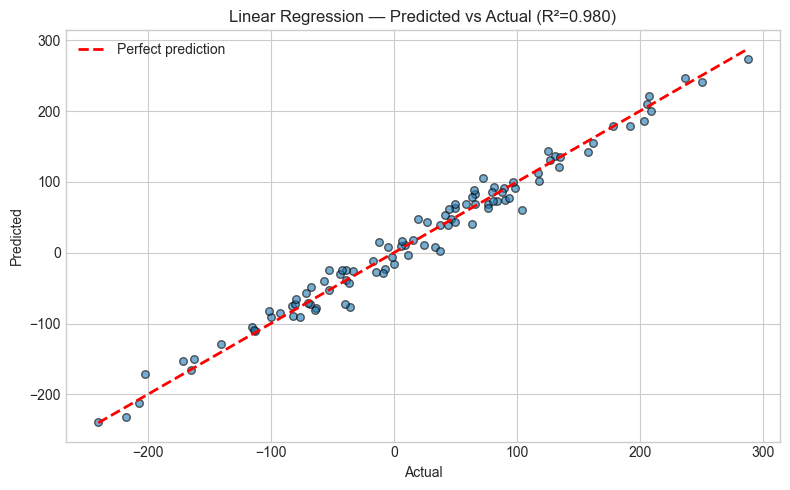

In [6]:
# Predicted vs Actual scatter plot
fig, ax = plt.subplots()
ax.scatter(y_reg_test, y_pred_lr, alpha=0.6, edgecolors='k', s=30)
lims = [min(y_reg_test.min(), y_pred_lr.min()), max(y_reg_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Linear Regression — Predicted vs Actual (R²={r2_lr:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


### 5. Ridge & Lasso Regression (Regularisation)

Regularisation adds a **penalty** to the loss function to discourage large coefficients and reduce overfitting.

| Method | Penalty | Effect |
|--------|---------|--------|
| **Ridge** (L2) | $\alpha \sum w_j^2$ | Shrinks coefficients toward zero |
| **Lasso** (L1) | $\alpha \sum |w_j|$ | Can set coefficients **exactly** to zero → feature selection |

The hyperparameter **α** controls penalty strength.

> ⚠️ Large α = more regularisation = simpler model (possibly underfitting).


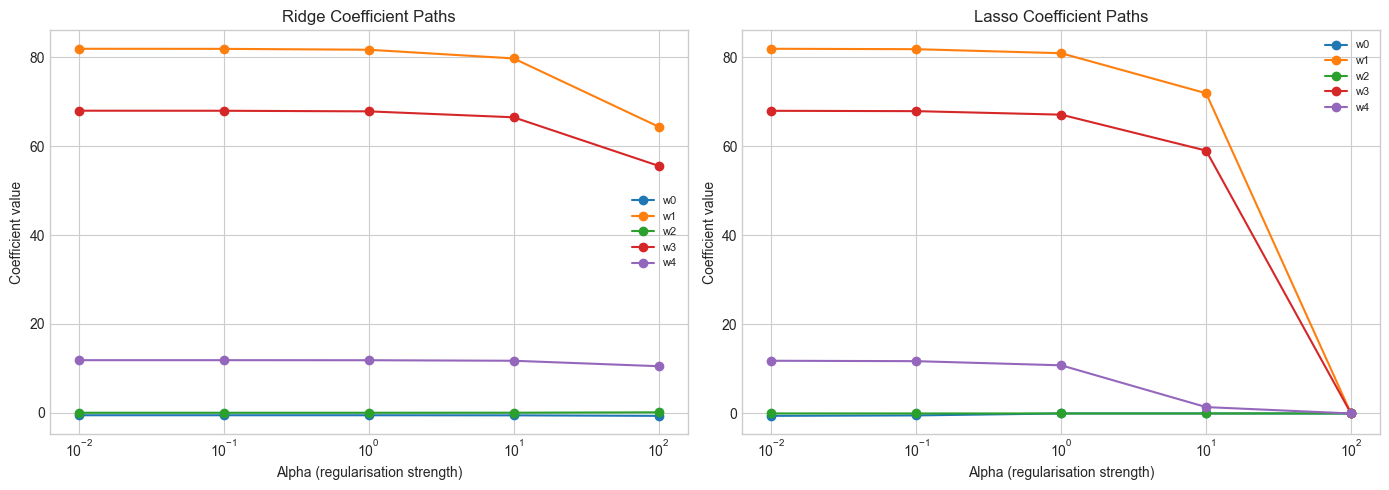

In [7]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_coefs, lasso_coefs = [], []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_reg_train, y_reg_train)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_reg_train, y_reg_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

# Compare coefficient paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (coefs, name) in enumerate([(ridge_coefs, 'Ridge'), (lasso_coefs, 'Lasso')]):
    ax = axes[i]
    coef_arr = np.array(coefs)
    for j in range(coef_arr.shape[1]):
        ax.plot(alphas, coef_arr[:, j], marker='o', label=f'w{j}')
    ax.set_xscale('log')
    ax.set_xlabel('Alpha (regularisation strength)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(f'{name} Coefficient Paths')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 6. Decision Tree Regressor

A Decision Tree recursively splits the feature space into rectangular regions and predicts the mean target value in each region.

- **Pro:** captures non-linear relationships, highly interpretable
- **Con:** prone to **overfitting** if the tree is not constrained (max_depth, min_samples_leaf)

Below we demonstrate overfitting by comparing an unconstrained tree to a depth-limited one.


Unconstrained   → Train R²: 1.0000  |  Test R²: 0.8895
max_depth=4     → Train R²: 0.9006  |  Test R²: 0.8145


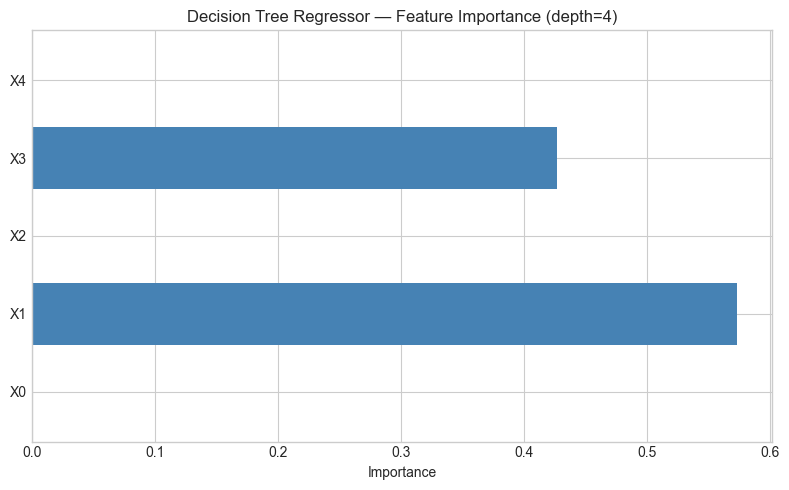

In [8]:
from sklearn.tree import DecisionTreeRegressor

# Overfit tree
dt_overfit = DecisionTreeRegressor(random_state=42)          # no depth limit
dt_overfit.fit(X_reg_train, y_reg_train)

# Constrained tree
dt_pruned = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_pruned.fit(X_reg_train, y_reg_train)

for name, model in [('Unconstrained', dt_overfit), ('max_depth=4', dt_pruned)]:
    train_r2 = r2_score(y_reg_train, model.predict(X_reg_train))
    test_r2  = r2_score(y_reg_test,  model.predict(X_reg_test))
    print(f"{name:15s} → Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")

# Feature importance
importances = dt_pruned.feature_importances_
feat_names = [f"X{i}" for i in range(X_reg.shape[1])]

fig, ax = plt.subplots()
ax.barh(feat_names, importances, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Decision Tree Regressor — Feature Importance (depth=4)')
plt.tight_layout()
plt.show()


### 7. Regression Model Comparison

Let's place all regressors side by side and compare their R² and RMSE on the test set.


                  R²     RMSE
Model                        
Linear        0.9798  15.3434
Ridge(α=1)    0.9797  15.3598
Lasso(α=1)    0.9795  15.4554
DT(depth=4)   0.8145  46.4689
DT(no limit)  0.8895  35.8596


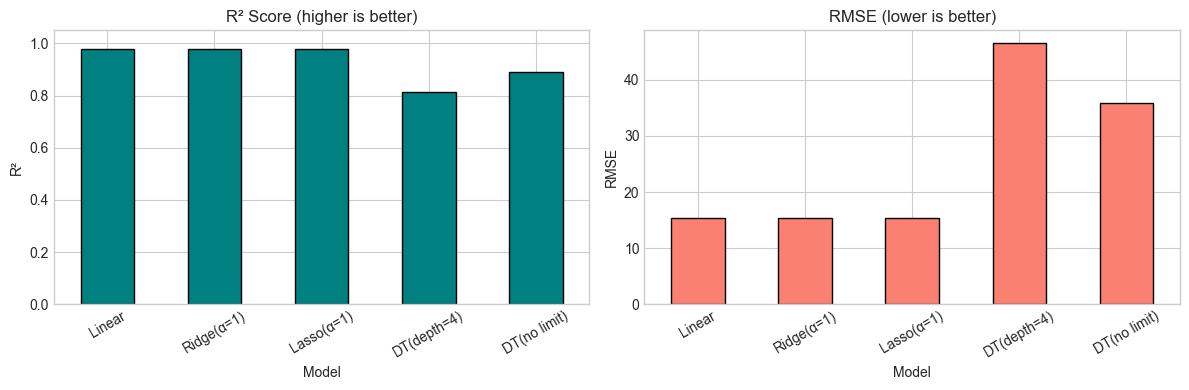

In [9]:
from sklearn.linear_model import Ridge, Lasso

models_reg = {
    'Linear':       LinearRegression(),
    'Ridge(α=1)':   Ridge(alpha=1.0),
    'Lasso(α=1)':   Lasso(alpha=1.0, max_iter=10000),
    'DT(depth=4)':  DecisionTreeRegressor(max_depth=4, random_state=42),
    'DT(no limit)': DecisionTreeRegressor(random_state=42),
}

results_reg = []
for name, m in models_reg.items():
    m.fit(X_reg_train, y_reg_train)
    preds = m.predict(X_reg_test)
    results_reg.append({
        'Model': name,
        'R²': r2_score(y_reg_test, preds),
        'RMSE': root_mean_squared_error(y_reg_test, preds),
    })

df_reg = pd.DataFrame(results_reg).set_index('Model')
print(df_reg.round(4))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_reg['R²'].plot.bar(ax=axes[0], color='teal', edgecolor='k')
axes[0].set_title('R² Score (higher is better)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)

df_reg['RMSE'].plot.bar(ax=axes[1], color='salmon', edgecolor='k')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


---
## Part 3: Classification

Classification models predict a **discrete** label (e.g., spam / not-spam).  We will train several classifiers on both the 10-feature and 2-feature classification datasets.


### 8. Logistic Regression

Despite its name, Logistic Regression is a **classification** algorithm.  It models the probability of class 1 using the sigmoid function:

$$P(y=1|X) = \sigma(X\mathbf{w} + b) = \frac{1}{1 + e^{-(X\mathbf{w}+b)}}$$

A threshold (usually 0.5) converts probabilities into class labels.


Logistic Regression accuracy (2D): 0.8250


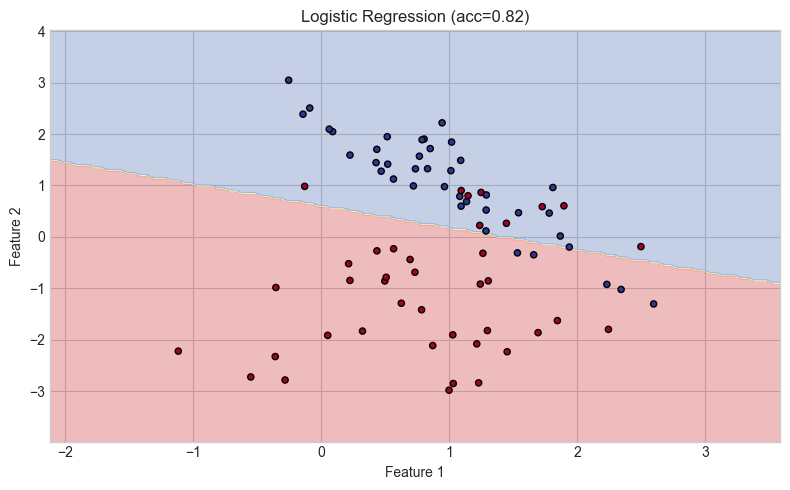

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_2d_train, y_2d_train)

acc_lr = accuracy_score(y_2d_test, logreg.predict(X_2d_test))
print(f"Logistic Regression accuracy (2D): {acc_lr:.4f}")

fig, ax = plt.subplots()
plot_decision_boundary(logreg, X_2d_test, y_2d_test, ax=ax,
                       title=f'Logistic Regression (acc={acc_lr:.2f})')
plt.tight_layout()
plt.show()


### 9. K-Nearest Neighbors (KNN)

KNN classifies a new point by a **majority vote** of its *k* closest training neighbours.

- Small *k* → complex boundary (may overfit)
- Large *k* → smoother boundary (may underfit)

No explicit model is stored — KNN is a *lazy learner*.


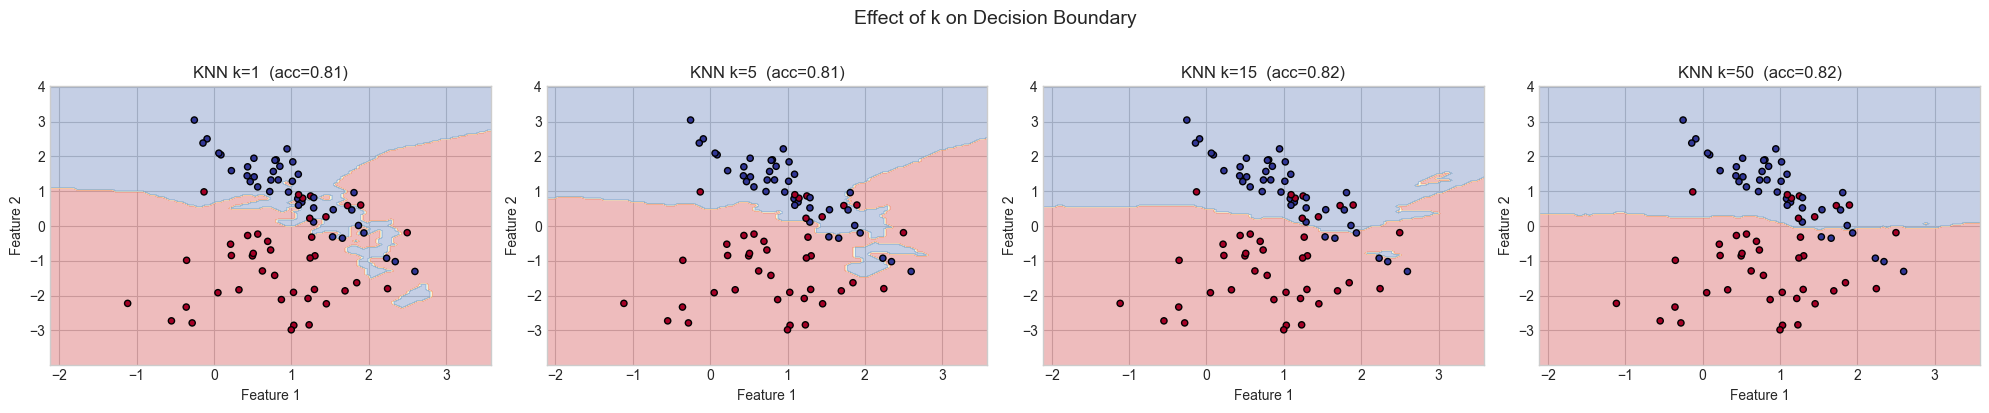

In [11]:
from sklearn.neighbors import KNeighborsClassifier

ks = [1, 5, 15, 50]
fig, axes = plt.subplots(1, len(ks), figsize=(5 * len(ks), 4))

for ax, k in zip(axes, ks):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_2d_train, y_2d_train)
    acc = accuracy_score(y_2d_test, knn.predict(X_2d_test))
    plot_decision_boundary(knn, X_2d_test, y_2d_test, ax=ax,
                           title=f'KNN k={k}  (acc={acc:.2f})')

plt.suptitle('Effect of k on Decision Boundary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 10. Decision Tree Classifier

Works the same way as the regression tree but optimises **Gini impurity** (or entropy) instead of MSE.

Feature importance tells us which features the tree relied on most for splitting.


Decision Tree accuracy: 0.8917


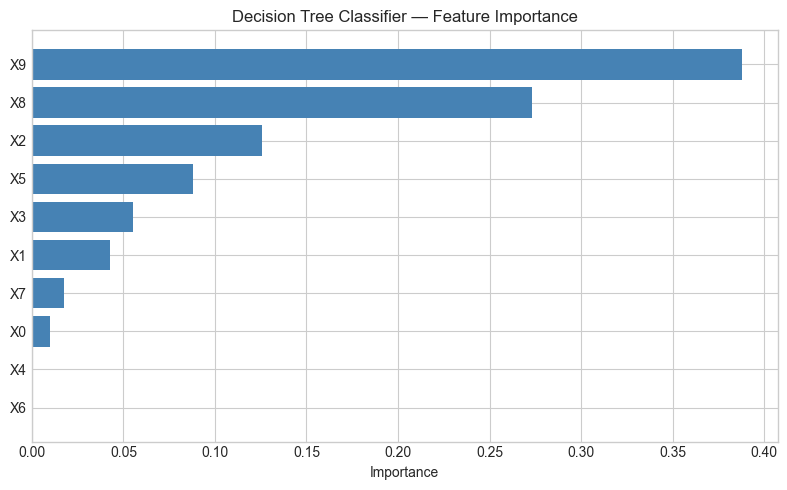

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_clf_train, y_clf_train)
acc_dt = accuracy_score(y_clf_test, dt_clf.predict(X_clf_test))
print(f"Decision Tree accuracy: {acc_dt:.4f}")

# Feature importance
feat_names_clf = [f"X{i}" for i in range(X_clf.shape[1])]
importances = dt_clf.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh([feat_names_clf[i] for i in idx], importances[idx], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Decision Tree Classifier — Feature Importance')
plt.tight_layout()
plt.show()


### 11. Random Forest Classifier

A Random Forest is an **ensemble** of Decision Trees.  Each tree is trained on a random bootstrap sample with a random subset of features.  The final prediction is a majority vote across all trees.

- Reduces the variance / overfitting of a single tree
- Provides robust feature-importance estimates


Random Forest accuracy: 0.9583
Decision Tree accuracy: 0.8917  (for comparison)


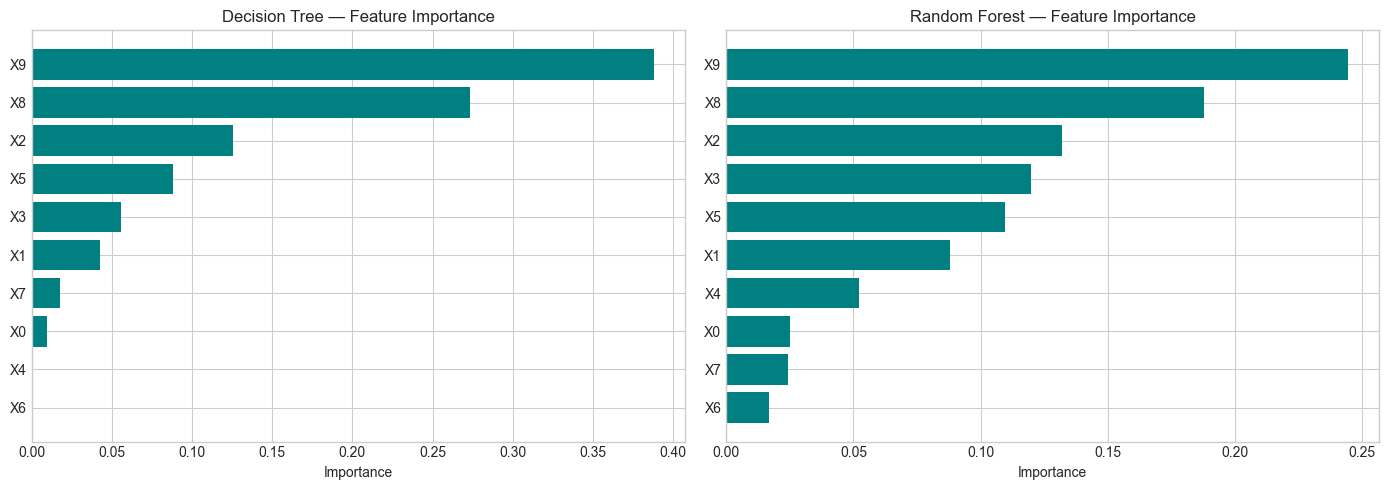

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_clf_train, y_clf_train)
acc_rf = accuracy_score(y_clf_test, rf_clf.predict(X_clf_test))
print(f"Random Forest accuracy: {acc_rf:.4f}")
print(f"Decision Tree accuracy: {acc_dt:.4f}  (for comparison)")

# Compare feature importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name in zip(axes, [dt_clf, rf_clf], ['Decision Tree', 'Random Forest']):
    imp = model.feature_importances_
    idx = np.argsort(imp)
    ax.barh([feat_names_clf[i] for i in idx], imp[idx], color='teal')
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} — Feature Importance')

plt.tight_layout()
plt.show()


### 12. Support Vector Machine (SVM)

SVM finds the hyperplane that maximises the **margin** between classes.

| Kernel | Boundary |
|--------|----------|
| `linear` | Straight line / hyperplane |
| `rbf` (Radial Basis Function) | Smooth, non-linear boundary |

The **C** parameter trades off margin width vs. classification error.

> 💡 SVMs work best on small-to-medium datasets.  For large data, prefer `LinearSVC` or tree-based models.


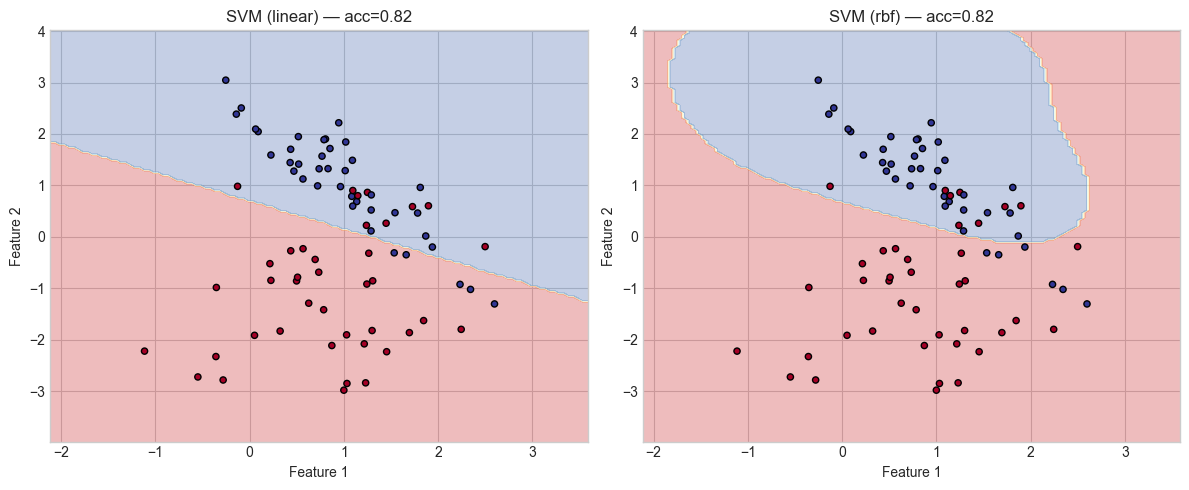

In [14]:
from sklearn.svm import SVC

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, kernel in zip(axes, ['linear', 'rbf']):
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_2d_train, y_2d_train)
    acc = accuracy_score(y_2d_test, svm.predict(X_2d_test))
    plot_decision_boundary(svm, X_2d_test, y_2d_test, ax=ax,
                           title=f'SVM ({kernel}) — acc={acc:.2f}')

plt.tight_layout()
plt.show()


### 13. Evaluation Deep Dive

Accuracy alone can be misleading (e.g., in imbalanced datasets).  We need a richer picture:

| Metric | Definition |
|--------|-----------|
| **Precision** | Of all predicted positives, how many are truly positive? TP / (TP+FP) |
| **Recall** (Sensitivity) | Of all actual positives, how many did we find? TP / (TP+FN) |
| **F1 Score** | Harmonic mean of Precision and Recall |

The **confusion matrix** visualises True/False Positives and Negatives in a grid.


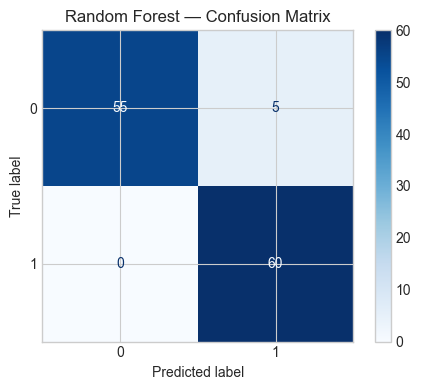

              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        60
     Class 1       0.92      1.00      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



In [15]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Use Random Forest on the 10-feature set
y_pred_rf = rf_clf.predict(X_clf_test)

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred_rf, ax=ax, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_clf_test, y_pred_rf, target_names=['Class 0', 'Class 1']))


### 14. ROC Curve & AUC

The **Receiver Operating Characteristic** (ROC) curve plots True Positive Rate vs. False Positive Rate at varying classification thresholds.

- **AUC** (Area Under the Curve) summarises the curve in a single number (1.0 = perfect, 0.5 = random guess).
- The closer the curve hugs the top-left corner, the better.

We will overlay ROC curves for several classifiers trained on the same 10-feature dataset.


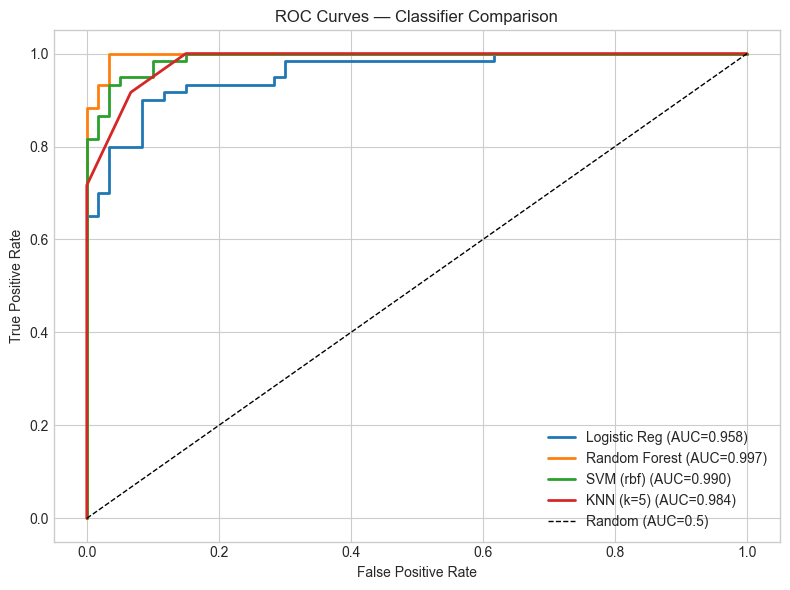

In [16]:
from sklearn.metrics import roc_curve, auc

classifiers = {
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM (rbf)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

fig, ax = plt.subplots(figsize=(8, 6))

for name, clf in classifiers.items():
    clf.fit(X_clf_train, y_clf_train)
    # Get probability estimates
    if hasattr(clf, 'predict_proba'):
        y_scores = clf.predict_proba(X_clf_test)[:, 1]
    else:
        y_scores = clf.decision_function(X_clf_test)
    fpr, tpr, _ = roc_curve(y_clf_test, y_scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classifier Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 15. Classification Model Comparison

Let's compare all classifiers on accuracy and macro-averaged F1 score using the 10-feature dataset.


               Accuracy      F1
Model                          
Logistic Reg     0.8917  0.8915
KNN (k=5)        0.9250  0.9246
Decision Tree    0.8917  0.8911
Random Forest    0.9583  0.9583
SVM (rbf)        0.9333  0.9332


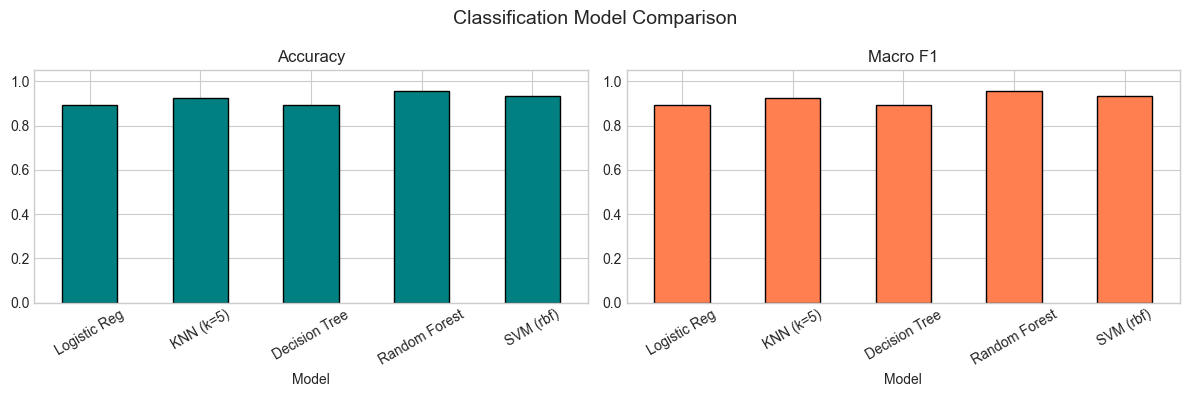

In [17]:
from sklearn.metrics import f1_score

all_classifiers = {
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)':    KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM (rbf)':    SVC(kernel='rbf', random_state=42),
}

results_clf = []
for name, clf in all_classifiers.items():
    clf.fit(X_clf_train, y_clf_train)
    preds = clf.predict(X_clf_test)
    results_clf.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clf_test, preds),
        'F1': f1_score(y_clf_test, preds, average='macro'),
    })

df_clf = pd.DataFrame(results_clf).set_index('Model')
print(df_clf.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clf['Accuracy'].plot.bar(ax=axes[0], color='teal', edgecolor='k')
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1.05)
df_clf['F1'].plot.bar(ax=axes[1], color='coral', edgecolor='k')
axes[1].set_title('Macro F1')
axes[1].set_ylim(0, 1.05)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Classification Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


---
## Part 4: Unsupervised Learning

In unsupervised learning there are **no labels**.  The goal is to discover hidden structure: groups, low-dimensional representations, or latent patterns.


### 16. K-Means Clustering

K-Means partitions data into *k* clusters by iteratively:
1. Assigning each point to the nearest centroid
2. Recomputing each centroid as the mean of its assigned points

**Choosing k:** The **elbow method** plots inertia (within-cluster sum of squares) vs. k and looks for the "elbow" where adding more clusters yields diminishing returns.


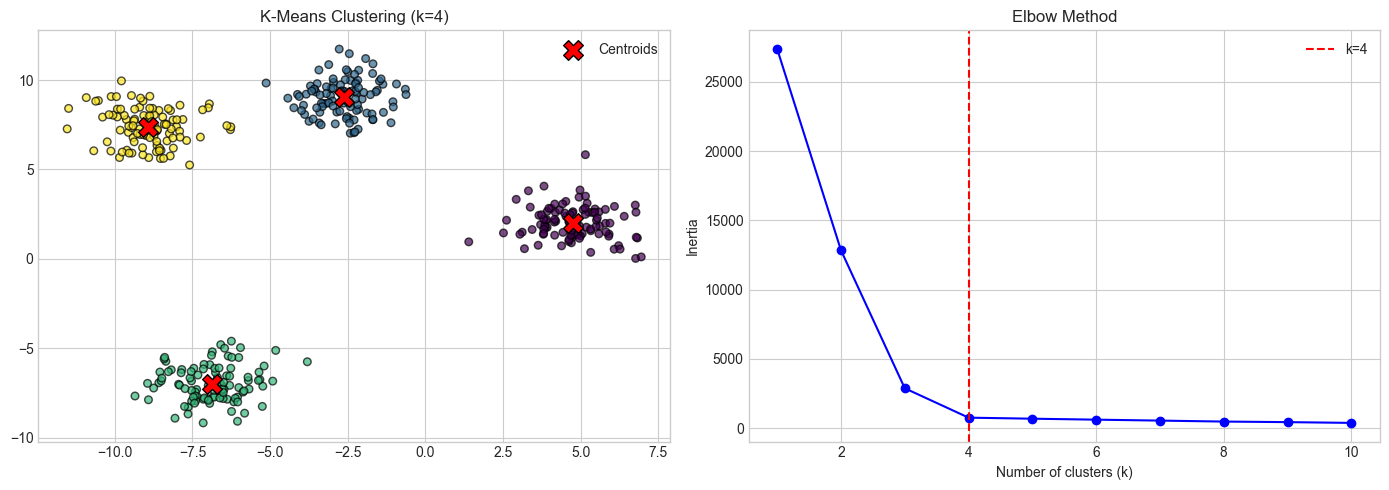

In [18]:
from sklearn.cluster import KMeans

# Fit K-Means with true k=4
km = KMeans(n_clusters=4, n_init=10, random_state=42)
km.fit(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot clusters
ax = axes[0]
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=km.labels_, cmap='viridis',
           edgecolors='k', s=30, alpha=0.7)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='k', label='Centroids')
ax.set_title('K-Means Clustering (k=4)')
ax.legend()

# Elbow method
inertias = []
K = range(1, 11)
for k in K:
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs).inertia_)

ax = axes[1]
ax.plot(K, inertias, 'bo-')
ax.axvline(x=4, color='red', linestyle='--', label='k=4')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method')
ax.legend()

plt.tight_layout()
plt.show()


### 17. Principal Component Analysis (PCA)

PCA projects high-dimensional data onto a lower-dimensional subspace that **maximises variance**.

- The first principal component captures the most variance, the second captures the next most, and so on.
- Useful for visualisation (projecting to 2D) and noise reduction.

We will apply PCA to our 10-feature classification dataset and see how much variance each component explains.


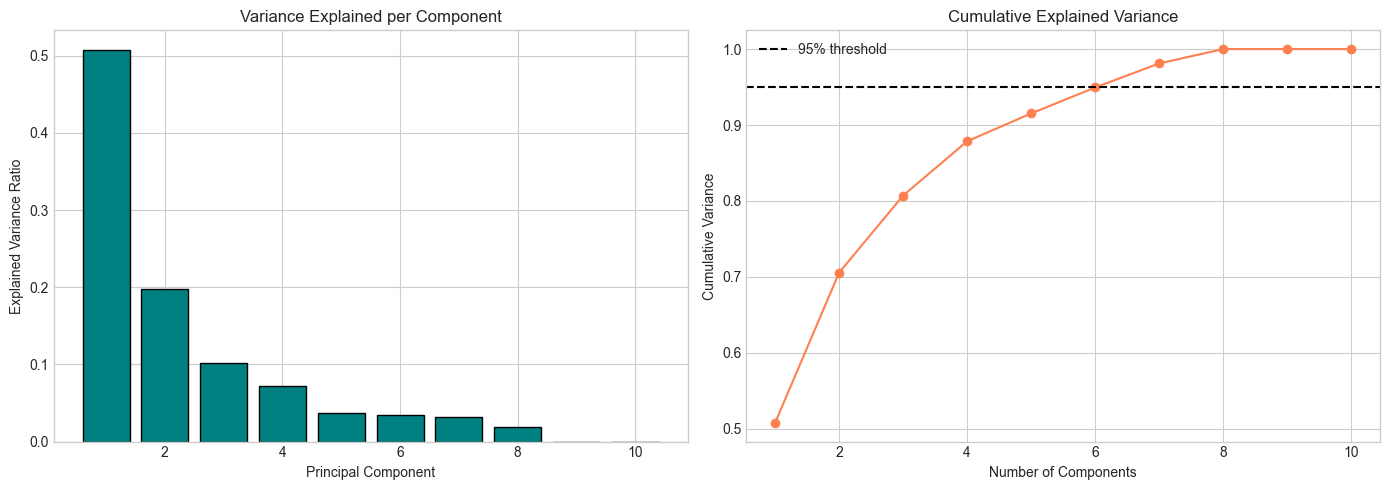

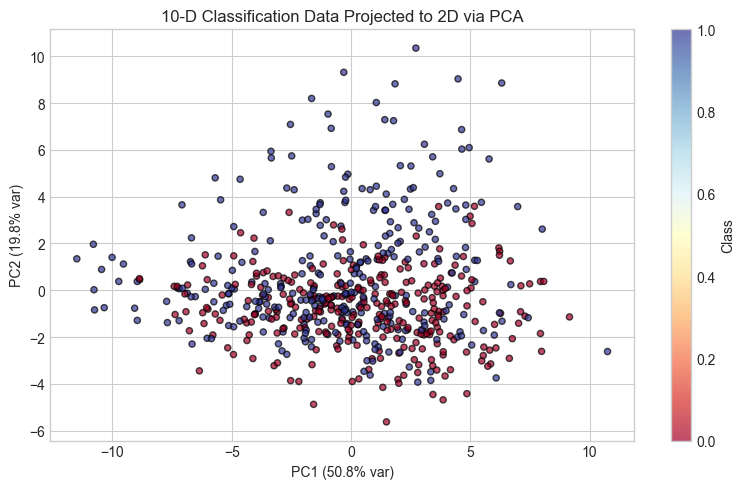

In [19]:
from sklearn.decomposition import PCA

# Full PCA
pca_full = PCA().fit(X_clf)

# Explained variance ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='teal', edgecolor='k')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained per Component')

axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             np.cumsum(pca_full.explained_variance_ratio_), 'o-', color='coral')
axes[1].axhline(y=0.95, color='k', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Project to 2D for visualisation
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_clf)

fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap='RdYlBu',
                     edgecolors='k', s=20, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('10-D Classification Data Projected to 2D via PCA')
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.show()


### 18. Combining PCA + K-Means

A common pattern: reduce dimensionality with PCA first, then cluster in the lower-dimensional space. This can improve clustering speed and quality by removing noise.


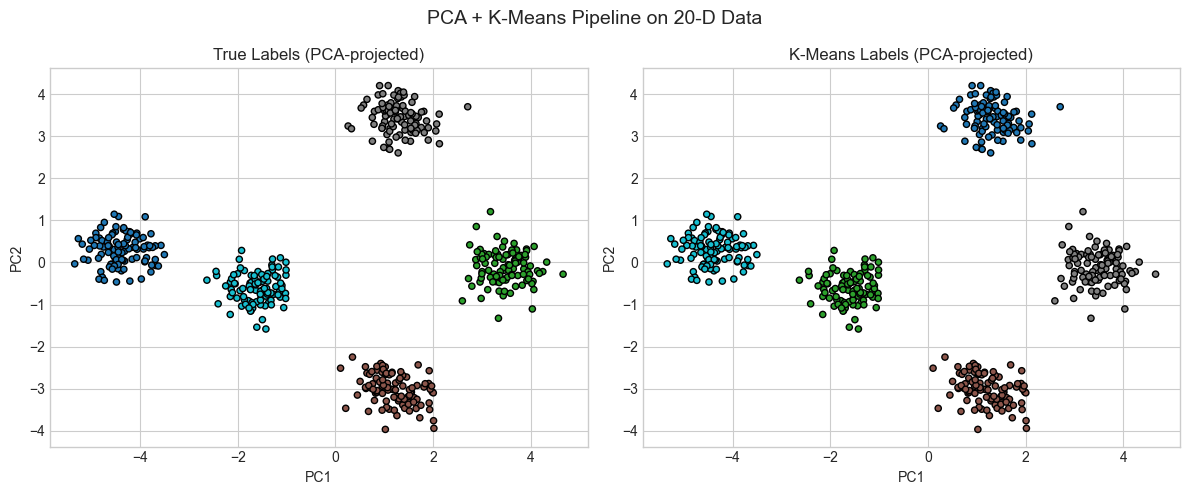

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Generate a higher-dimensional blob dataset
X_hd, y_hd = make_blobs(n_samples=500, centers=5, n_features=20,
                          cluster_std=2.0, random_state=42)

# Pipeline: Scale → PCA → K-Means
pipe_cluster = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('kmeans', KMeans(n_clusters=5, n_init=10, random_state=42)),
])

labels = pipe_cluster.fit_predict(X_hd)

# Visualise in PCA space
X_vis = pipe_cluster[:2].transform(X_hd)  # scaler + PCA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=y_hd, cmap='tab10', edgecolors='k', s=20)
axes[0].set_title('True Labels (PCA-projected)')
axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab10', edgecolors='k', s=20)
axes[1].set_title('K-Means Labels (PCA-projected)')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.suptitle('PCA + K-Means Pipeline on 20-D Data', fontsize=14)
plt.tight_layout()
plt.show()


---
## Part 5: Model Tuning & Pipelines

Once you have a baseline model, the next step is to **tune hyperparameters** and build reproducible **pipelines**.

### Why Pipelines?
- Guarantee that preprocessing steps (scaling, imputation) are fit on training data only
- Prevent data leakage
- Make code cleaner and deployable


### 19. Cross-Validation

Instead of a single train/test split, **k-fold cross-validation** splits the data into *k* folds.  The model is trained *k* times, each time using a different fold as the validation set.

```
Fold 1: [VAL] [train] [train] [train] [train]
Fold 2: [train] [VAL] [train] [train] [train]
Fold 3: [train] [train] [VAL] [train] [train]
Fold 4: [train] [train] [train] [VAL] [train]
Fold 5: [train] [train] [train] [train] [VAL]
```

This gives a more reliable performance estimate and a standard deviation that reflects variance across splits.


In [21]:
from sklearn.model_selection import cross_val_score

cv_models = {
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'SVM (rbf)':     SVC(kernel='rbf', random_state=42),
}

print(f"{'Model':20s} {'Mean Acc':>10s} {'Std':>8s}")
print('-' * 40)
for name, model in cv_models.items():
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    print(f"{name:20s} {scores.mean():10.4f} {scores.std():8.4f}")


Model                  Mean Acc      Std
----------------------------------------
Logistic Reg             0.8567   0.0406


Random Forest            0.8900   0.0322
KNN (k=5)                0.8850   0.0291
SVM (rbf)                0.9017   0.0213


### 20. GridSearchCV — Systematic Hyperparameter Tuning

`GridSearchCV` exhaustively searches over a parameter grid, evaluating each combination with cross-validation.

We will tune a Random Forest's `n_estimators`, `max_depth`, and `min_samples_split`.

> 💡 For large grids, consider `RandomizedSearchCV` which samples a fixed number of combinations instead of trying all.


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    verbose=0,
)
grid_search.fit(X_clf_train, y_clf_train)

print(f"Best params : {grid_search.best_params_}")
print(f"Best CV acc : {grid_search.best_score_:.4f}")
print(f"Test acc    : {grid_search.score(X_clf_test, y_clf_test):.4f}")


Best params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV acc : 0.8896
Test acc    : 0.9500


### 21. Building a Complete sklearn Pipeline

A `Pipeline` chains multiple preprocessing and modelling steps into a single estimator.  This example demonstrates:

1. **StandardScaler** — centre and scale features
2. **SimpleImputer** — fill missing values (even though our synthetic data has none, it's good practice)
3. **RandomForestClassifier** — the final estimator

The pipeline can be passed directly to `cross_val_score` or `GridSearchCV`.


In [23]:
from sklearn.impute import SimpleImputer

full_pipeline = Pipeline([
    ('scaler',  StandardScaler()),
    ('imputer', SimpleImputer(strategy='mean')),
    ('model',   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
])

# Cross-validated evaluation
scores = cross_val_score(full_pipeline, X_clf, y_clf, cv=5, scoring='accuracy')
print(f"Pipeline CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Fit on training set and evaluate on test set
full_pipeline.fit(X_clf_train, y_clf_train)
test_acc = full_pipeline.score(X_clf_test, y_clf_test)
print(f"Pipeline Test Accuracy: {test_acc:.4f}")


Pipeline CV Accuracy: 0.8900 ± 0.0322
Pipeline Test Accuracy: 0.9583


### 22. Learning Curves

A learning curve plots **training** and **validation** scores as a function of the training-set size.

| Pattern | Diagnosis |
|---------|-----------|
| Both scores high, converging | Good fit ✅ |
| Training high, validation low | **Overfitting** — need more data or regularisation |
| Both scores low | **Underfitting** — need a more complex model or better features |


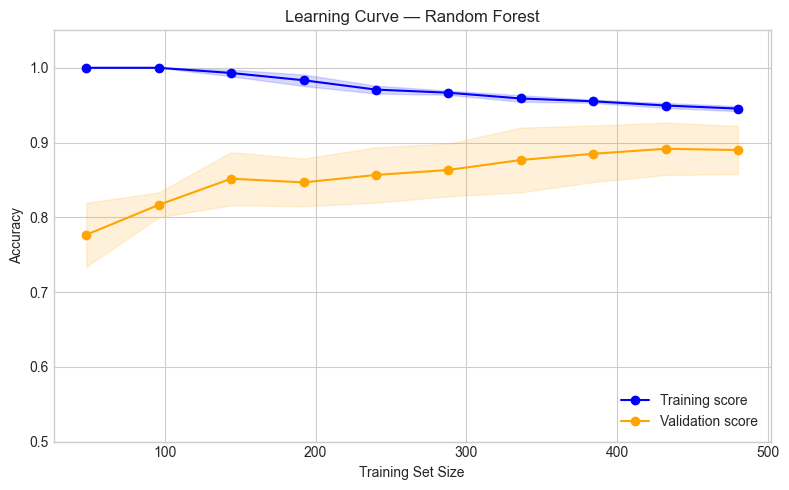

In [24]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    X_clf, y_clf,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots()
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation score')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Random Forest')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()


---
## Part 6: Wrap-up

### 23. Algorithm Cheat Sheet

| Algorithm | Type | Best For | Key Hyperparameters | Pros | Cons |
|-----------|------|----------|---------------------|------|------|
| **Linear Regression** | Regression | Linear relationships | — | Fast, interpretable | Assumes linearity |
| **Ridge / Lasso** | Regression | Regularised regression | α | Handles multicollinearity; Lasso does feature selection | Still linear |
| **Decision Tree** | Both | Non-linear data, interpretability | max_depth, min_samples_split | Easy to understand | Overfits easily |
| **Random Forest** | Both | General-purpose, tabular data | n_estimators, max_depth | Low variance, robust | Slower, less interpretable |
| **Logistic Regression** | Classification | Baseline classifier | C, penalty | Fast, probabilistic | Linear boundary |
| **KNN** | Classification | Small datasets | k (n_neighbors) | No training needed | Slow at prediction, curse of dimensionality |
| **SVM** | Classification | Small-medium datasets | C, kernel, gamma | Works well in high dimensions | Doesn't scale to large *n* |
| **K-Means** | Clustering | Globular clusters | k (n_clusters) | Simple, fast | Must specify *k*, assumes spherical clusters |
| **PCA** | Dim. Reduction | Visualisation, noise reduction | n_components | Fast, variance-preserving | Linear only |

> 💡 **Rule of thumb:** Start simple (linear models), then add complexity only if needed.


### 24. 🏋️ Exercise: Build Your Own Pipeline

Using the synthetic dataset generated below, your task is to:

1. Split the data into train and test sets (80/20, stratified)
2. Build a `Pipeline` with scaling and a classifier of your choice
3. Use `GridSearchCV` to tune at least 2 hyperparameters
4. Evaluate on the test set and print the confusion matrix
5. Plot the ROC curve

Good luck! 🚀


In [25]:
# === EXERCISE DATASET — DO NOT MODIFY ===
from sklearn.datasets import make_classification

X_exercise, y_exercise = make_classification(
    n_samples=800, n_features=15, n_informative=8,
    n_redundant=3, n_classes=2, weights=[0.6, 0.4],
    random_state=99
)

print(f"Exercise dataset → X: {X_exercise.shape}, y: {y_exercise.shape}")
print(f"Class distribution: {np.bincount(y_exercise)}")

# ──────────────────────────────────────────
# YOUR CODE BELOW
# ──────────────────────────────────────────

# Step 1: Train/test split

# Step 2: Build pipeline

# Step 3: GridSearchCV

# Step 4: Evaluate — confusion matrix

# Step 5: ROC curve


Exercise dataset → X: (800, 15), y: (800,)
Class distribution: [478 322]


### 25. 🚀 Next Steps

Congratulations!  You now have a solid foundation in classical Machine Learning with scikit-learn.

**Where to go from here:**

| Topic | Resource |
|-------|----------|
| **Deep Learning** | Check out the deep-learning notebook in this series |
| **Feature Engineering** | Learn about encoding categoricals, creating interaction features, handling dates |
| **Advanced Ensembles** | XGBoost, LightGBM, CatBoost — gradient-boosted trees dominate tabular data competitions |
| **Model Interpretability** | SHAP values, LIME, permutation importance |
| **MLOps** | Experiment tracking (MLflow), model serving (FastAPI, TF Serving) |

> 📚 **Recommended reading:** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* by Aurélien Géron.

---

*Notebook created as part of the ML Fundamentals series.*
